In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
import csv
from decimal import Decimal
from IPython.display import display, Math
import math

In [2]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [3]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [4]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_model : array_like
        Model predictions.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    n_params : int
        Number of fitted parameters.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs)
    y_model = np.asarray(y_model)
    y_err_low = np.asarray(y_err_low)
    y_err_high = np.asarray(y_err_high)

    # Use the appropriate uncertainty depending on which side of the data
    sigma = np.where(y_model > y_obs, y_err_high, y_err_low)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [5]:
def uncertainty_propagation(parameters, equation, n_samples=10000):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    
    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model
    values = equation(samples) # rows of output_i = equation(param1_i, param2_i,...)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    return med, high - med, med - low

In [6]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label,
                              colour,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_uncertainty : float
        1-sigma uncertainty on slope.
    intercept_uncertainty : float
        1-sigma uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    """

    if line_kwargs is None:
        line_kwargs = {"color": colour, "lw": 2}

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    x_plot = np.linspace(np.min(x)*0.95, np.max(x)*1.05, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_uncertainty) * x_plot
               + (intercept + intercept_uncertainty))

    y_lower = ((gradient - gradient_uncertainty) * x_plot
               + (intercept - intercept_uncertainty))

    ax.plot(x_plot, y, **line_kwargs, label=label,zorder=zorder)
    ax.fill_between(x_plot, y_lower, y_upper, **band_kwargs)
    ax.legend()

In [7]:

def format_value_uncertainty(value, uncertainty):
    """
    Format a value ± uncertainty using standard significant-figure rules.
    """
    if uncertainty == 0:
        return f"{value:.3f}", "0"

    # 1 significant figure (2 if first digit is 1 or 2)
    exponent = math.floor(math.log10(abs(uncertainty)))
    first_digit = int(abs(uncertainty) / 10**exponent)

    sig_figs = 2 if first_digit in [1, 2] else 1

    decimals = -(exponent - (sig_figs - 1))

    value_rounded = round(value, decimals)
    uncertainty_rounded = round(uncertainty, decimals)

    fmt = f"{{:.{max(decimals,0)}f}}"

    return fmt.format(value_rounded), fmt.format(uncertainty_rounded)

In [8]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl


In [9]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [10]:
def filter_best_DIC(stellar_table, stellar_AGN_table):
    """
    Select the stellar mass from either the stellar-only or stellar+AGN fit
    depending on the DIC comparison.

    Uses the AGN model if:
        DIC_AGN < DIC_stellar - 5

    Returns a table containing the best stellar mass estimates and the model
    selected for each galaxy.
    """

    # Match galaxies by ID
    # Some of the headers are the same across both tables, so to avoid confusion, 
    # uniq_col_name keeps the col_name and appends it with stellar or AGN depending on which table it came from.
    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # Read the relevant columns
    DIC_stellar = np.asarray(table["DIC_stellar"], dtype=float)
    DIC_AGN = np.asarray(table["DIC_AGN"], dtype=float)

    mass_stellar_Q16 = np.asarray(table["StellarMassQ16_stellar"], dtype=float)
    mass_stellar_Q50 = np.asarray(table["StellarMassQ50_stellar"], dtype=float)
    mass_stellar_Q84 = np.asarray(table["StellarMassQ84_stellar"], dtype=float)

    mass_AGN_Q16 = np.asarray(table["StellarMassQ16_AGN"], dtype=float)
    mass_AGN_Q50 = np.asarray(table["StellarMassQ50_AGN"], dtype=float)
    mass_AGN_Q84 = np.asarray(table["StellarMassQ84_AGN"], dtype=float)

    # Decide which model to use
    use_AGN = np.zeros(len(table), dtype=bool)

    mask = ~np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)
    use_AGN[mask] = DIC_AGN[mask] < (DIC_stellar[mask] - 5)

    # If only AGN exists, use it
    use_AGN[np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)] = True

    # Select best masses
    best_mass_Q16 = np.where(use_AGN, mass_AGN_Q16, mass_stellar_Q16)
    best_mass_Q50 = np.where(use_AGN, mass_AGN_Q50, mass_stellar_Q50)
    best_mass_Q84 = np.where(use_AGN, mass_AGN_Q84, mass_stellar_Q84)
    best_model = np.where(use_AGN, "stellar_AGN", "stellar")

    table["Best_StellarMassQ16"] = best_mass_Q16
    table["Best_StellarMassQ50"] = best_mass_Q50
    table["Best_StellarMassQ84"] = best_mass_Q84
    table["Best_Model"] = best_model

    print("DIC filtered table names: ",table.colnames)
    
    return table

In [11]:
def plot_stellar_masses(stellar_only_q16,stellar_only_mass_Q50,stellar_only_q84, stellar_AGN_q16,stellar_AGN_mass_Q50,stellar_AGN_q84):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_mass_Q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_mass_Q50)
    ]
    xerr = [
        np.log10(stellar_AGN_mass_Q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_mass_Q50)
    ]

    t, p = ttest_rel(stellar_only_mass_Q50, stellar_AGN_mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(
        np.log10(stellar_AGN_mass_Q50),
        np.log10(stellar_only_mass_Q50),
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_mass_Q50)),np.min(np.log10(stellar_only_mass_Q50)))
    mmax = max(np.max(np.log10(stellar_AGN_mass_Q50)),np.max(np.log10(stellar_only_mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)',fontdict={'fontsize': 15})
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [12]:
def check_Q50_mass_against_best(mass_Q16, mass_Q50, mass_Q84, mass_best):
    """
    Plotting stellar mass Q50 and errors (y-axis) against stellar mass best (x-axis).
    Will be done for stellar only data and stellar+AGN data when called separately.
    """
    
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(mass_Q50) - np.log10(mass_Q16),
        np.log10(mass_Q84) - np.log10(mass_Q50)]

    t, p = ttest_rel(mass_best, mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(mass_best),
        np.log10(mass_Q50),
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(mass_best)),np.min(np.log10(mass_Q50)))
    mmax = max(np.max(np.log10(mass_best)),np.max(np.log10(mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Best)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return

In [13]:
def bhsmr_eq(samples):
        
    bh_mass = samples[:,0]
    stellar_mass = samples[:,1]

    return np.log10(bh_mass / stellar_mass)

In [14]:
def bhsmr_plot(log10_bh_mass, log10_bh_mass_lower_err, log10_bh_mass_upper_err, mass_Q16, mass_Q50, mass_Q84):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)

    log10_mass_upper_err = np.log10(mass_Q84) - np.log10(mass_Q50)
    log10_mass_lower_err = np.log10(mass_Q50) - np.log10(mass_Q16)

    popt, pcov = curve_fit(straight_line, np.log10(mass_Q50), log10_bh_mass, p0=None)

    gradient = popt[0]
    intercept = popt[1]

    gradient_uncertainty = np.sqrt(np.diag(pcov))[0]
    intercept_uncertainty = np.sqrt(np.diag(pcov))[1]

    x_data = np.linspace(np.min(np.log10(mass_Q50)),np.max(np.log10(mass_Q50)),1000)
    # Model data for log10(stellar_mass/solar_mass)
    

    weighted_red_chi = weighted_reduced_chi_squared(log10_bh_mass, log10_bh_mass_lower_err, log10_bh_mass_upper_err, straight_line(np.log10(mass_Q50), gradient, intercept),2)


    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(
        np.log10(mass_Q50),
        (log10_bh_mass),
        xerr = [log10_mass_lower_err, log10_mass_upper_err],
        yerr=[log10_bh_mass_lower_err, log10_bh_mass_upper_err],
        fmt='none',
        alpha=0.15,
        lw=0.8,
        zorder=2
    )
    # I've plotted the errorbars separate to the plot to make them more transparent than the points
    ax.scatter(
        np.log10(mass_Q50),
        log10_bh_mass,
        s=20,
        color='C0',
        zorder=3
    )
    
    plot_best_fit_with_uncertainty(ax, x_data, gradient, intercept, gradient_uncertainty, intercept_uncertainty, "Line of best fit", "red",zorder=1)

    plot_best_fit_with_uncertainty(ax, x_data, RV_gradient, RV_intercept, RV_gradient_uncertainty, RV_intercept_uncertainty, "Reines & Volonteri", "black",zorder=1)

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    #plt.xlim(4,15)
    #ax.set_aspect('equal')
    ax.legend()
    plt.show()


    grad, grad_err = format_value_uncertainty(gradient, gradient_uncertainty)
    inter, inter_err = format_value_uncertainty(intercept, intercept_uncertainty)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))
    print(f"reduced chi squared = {weighted_red_chi:.3g}")



    RV_grad, RV_grad_err = format_value_uncertainty(RV_gradient, RV_gradient_uncertainty)
    RV_inter, RV_inter_err = format_value_uncertainty(RV_intercept, RV_intercept_uncertainty)
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_grad} \pm {RV_grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_inter} \pm {RV_inter_err})$"
    ))

    #------------------------------------------------------------------------------------------------------------------------------------------
    # Now calculating bhsmr and plotting against difference prosterior from ProSpect fit

    bh_mass_Q16 = 10**(log10_bh_mass - log10_bh_mass_lower_err)
    bh_mass_Q50 = 10**log10_bh_mass
    bh_mass_Q84 = 10**(log10_bh_mass + log10_bh_mass_upper_err)

    bhsmr = np.empty(len(log10_bh_mass))
    bhsmr_upper_err = np.empty(len(log10_bh_mass))
    bhsmr_lower_err = np.empty(len(log10_bh_mass))

    for i in range(len(log10_bh_mass)):
        bhsmr[i], bhsmr_upper_err[i], bhsmr_lower_err[i] = uncertainty_propagation([[bh_mass_Q16[i], bh_mass_Q50[i], bh_mass_Q84[i]], 
                                                                                    [mass_Q16[i], mass_Q50[i], mass_Q84[i]]], bhsmr_eq)        

    # Everything labelled with 2 henceforth pertains to bhsmr plot (even if not used in previous plots)
    
    popt2, pcov2 = curve_fit(straight_line, np.log10(mass_Q50), bhsmr, p0=None)

    gradient2 = popt2[0]
    intercept2 = popt2[1]

    gradient_uncertainty2 = np.sqrt(np.diag(pcov2))[0]
    intercept_uncertainty2 = np.sqrt(np.diag(pcov2))[1]

    x_data2 = np.linspace(np.min(np.log10(mass_Q50)),np.max(np.log10(mass_Q50)),1000)
    # Model data for log10(stellar_mass/solar_mass)
    
    weighted_red_chi2 = weighted_reduced_chi_squared(bhsmr, bhsmr_lower_err, bhsmr_upper_err, 
                                                     straight_line(np.log10(mass_Q50), gradient, intercept), 2)
    
    fig2, ax2 = plt.subplots(figsize=(10, 10))
    
    ax2.errorbar(
        np.log10(mass_Q50),
        bhsmr,
        xerr = [log10_mass_lower_err, log10_mass_upper_err],
        yerr = [bhsmr_lower_err, bhsmr_upper_err],
        fmt='none',
        alpha=0.15,
        lw=0.8,
        zorder=2
    )
    # I've plotted the errorbars separate to the plot to make them more transparent than the points
    ax2.scatter(
        np.log10(mass_Q50),
        bhsmr,
        s=20,
        color='C0',
        zorder=3
    )

    plot_best_fit_with_uncertainty(ax2, x_data2, gradient2, intercept2, gradient_uncertainty2, intercept_uncertainty2, "Line of best fit", "red",zorder=1) 
      
    ax2.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax2.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    #plt.xlim(4,15)
    #ax.set_aspect('equal')
    ax2.legend()
    plt.show()

    grad2, grad_err2 = format_value_uncertainty(gradient2, gradient_uncertainty2)
    inter2, inter_err2 = format_value_uncertainty(intercept2, intercept_uncertainty2)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))
    print(f"reduced chi squared = {weighted_red_chi2:.3g}")


    return bh_mass_Q16, bh_mass_Q50, bh_mass_Q84

In [15]:
#from xml.parsers.expat import model


def plot_AGNlum(stellar_table, stellar_AGN_table):

    """
    Plotting Q50 AGN luminosity against Q50 stellar mass, showing by colour which SED model was selected (stellar only or stellar+AGN).
    """
    DIC_filtered_table = filter_best_DIC(stellar_table, stellar_AGN_table)
    # Makes a combined table of data from both fits and appends new columns with mass_best etc. and the model selected for each galaxy (stellar only or stellar+AGN)

    stellar_mass_Q16 = DIC_filtered_table["Best_StellarMassQ16"].data
    stellar_mass_Q50 = DIC_filtered_table["Best_StellarMassQ50"].data
    stellar_mass_Q84 = DIC_filtered_table["Best_StellarMassQ84"].data

    model = DIC_filtered_table["Best_Model"].data
    AGNlum_Q16 = DIC_filtered_table["AGNlumQ16"].data
    AGNlum_Q50 = DIC_filtered_table["AGNlumQ50"].data
    AGNlum_Q84 = DIC_filtered_table["AGNlumQ84"].data
    
    xerr = [
        np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16),
        np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)]
    
    yerr = [
        np.log10(AGNlum_Q50) - np.log10(AGNlum_Q16),
        np.log10(AGNlum_Q84) - np.log10(AGNlum_Q50)]

    AGN = model == "stellar_AGN"
    stellar = model == "stellar"

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        xerr=[xerr[0][AGN], xerr[1][AGN]],
        yerr=[yerr[0][AGN], yerr[1][AGN]],
        fmt='None',
        color='red',
        lw=0.8,
        alpha=0.2,
        )

    ax.scatter(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        s=20,
        color='red',
        alpha=0.8,
        label='Stellar + AGN'
        )

    ax.errorbar(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        xerr=[xerr[0][stellar], xerr[1][stellar]],
        yerr=[yerr[0][stellar], yerr[1][stellar]],
        fmt='None',
        color='blue',
        lw=0.8,
        alpha=0.2,
        label='Stellar only'
    )

    ax.scatter(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        s=20,
        color='blue',
        alpha=0.8,
        label='Stellar only'
    )
    ax.legend()

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(L_{\rm AGN}/L_\odot)$ (AGN Luminosity Q50)',fontdict={'fontsize': 15})
    ax.legend(["Stellar + AGN", "Stellar only"])
    plt.show()

    #fig2, ax2 = plt.subplots(figsize=(10, 10))




p value =  0.1269779481726267


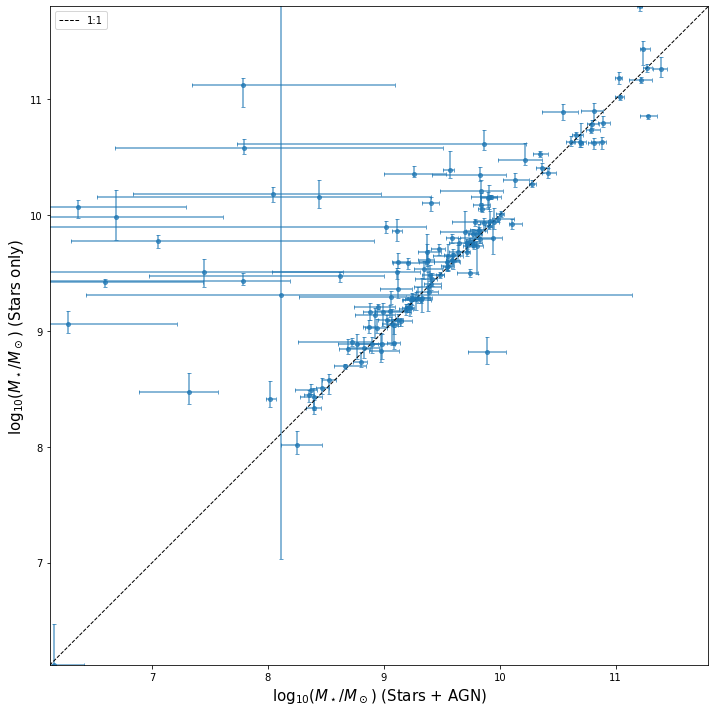

Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     70   144R x 31C   [D, 5A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 18A, 21A, J, D, D, D]   
Plot of black hole mass against stellar mass from SED fit of stellar light only


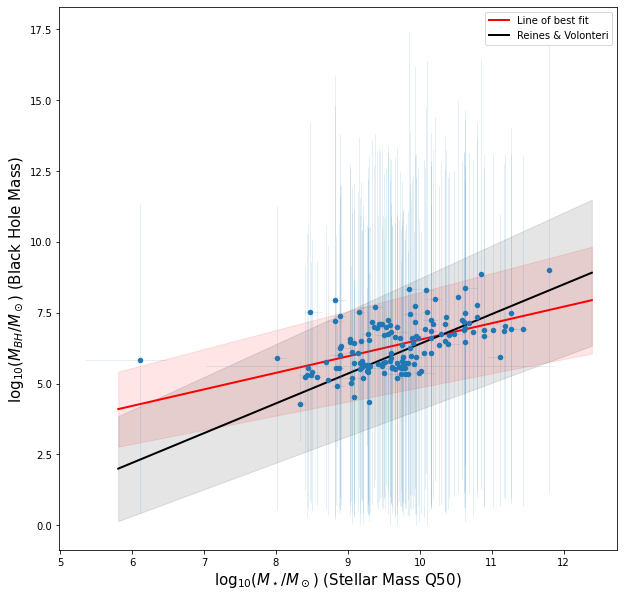

Line of best fit equation: 


<IPython.core.display.Math object>

reduced chi squared = 0.0253

Reines & Volonteri equation: 


<IPython.core.display.Math object>

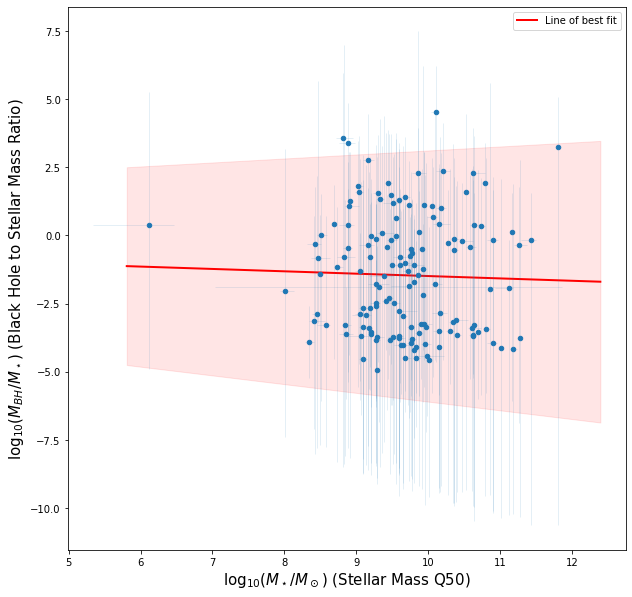

Line of best fit equation: 


<IPython.core.display.Math object>

reduced chi squared = 7.67
Plot of black hole mass against stellar mass from SED fit of stellar and AGN component


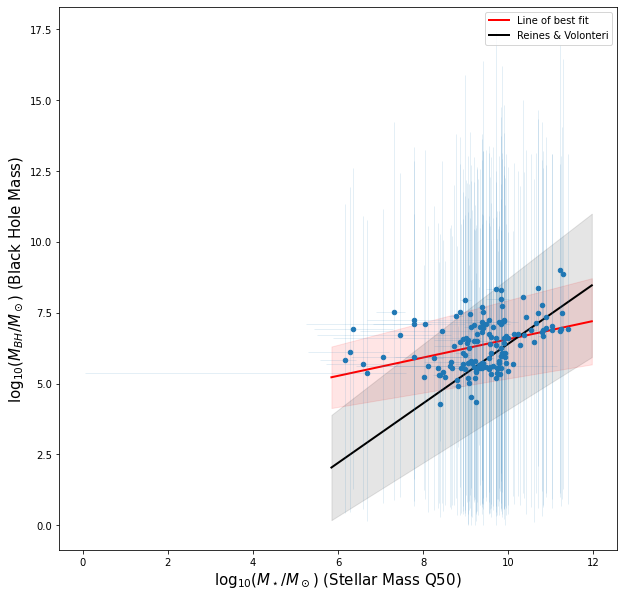

Line of best fit equation: 


<IPython.core.display.Math object>

reduced chi squared = 0.0343

Reines & Volonteri equation: 


<IPython.core.display.Math object>

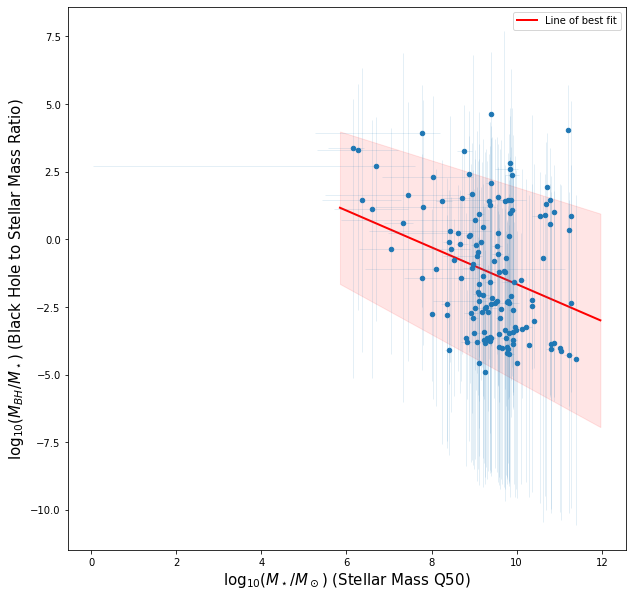

Line of best fit equation: 


<IPython.core.display.Math object>

reduced chi squared = 6.67
DIC filtered table names:  ['mSFRBest_stellar', 'mpeakBest_stellar', 'mperiodBest_stellar', 'mskewBest_stellar', 'tau_birthBest_stellar', 'tau_screenBest_stellar', 'alpha_SF_birthBest_stellar', 'alpha_SF_screenBest_stellar', 'ZfinalBest_stellar', 'StellarMassBest_stellar', 'SFR10Best_stellar', 'SFR100Best_stellar', 'UV1500Best_stellar', 'UV1500AGNBest_stellar', 'DustLumBirthBest_stellar', 'DustLumScreenBest_stellar', 'DustLumTotalBest_stellar', 'DustMassBirthBest_stellar', 'DustMassScreenBest_stellar', 'DustMassTotalBest_stellar', 'NgasMassBirthBest_stellar', 'NgasMassScreenBest_stellar', 'NgasMassTotalBest_stellar', 'LPBest_stellar', 'mSFRQ50_stellar', 'mpeakQ50_stellar', 'mperiodQ50_stellar', 'mskewQ50_stellar', 'tau_birthQ50_stellar', 'tau_screenQ50_stellar', 'alpha_SF_birthQ50_stellar', 'alpha_SF_screenQ50_stellar', 'ZfinalQ50_stellar', 'StellarMassQ50_stellar', 'SFR10Q50_stellar', 'SFR100Q50_stellar', 'UV1500Q50_stellar', 'UV1500AGNQ50_stellar', 'DustLum

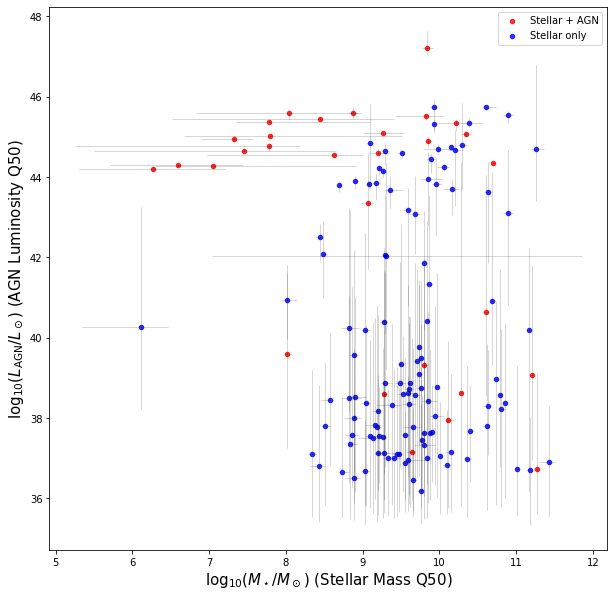

In [16]:
if __name__ == "__main__":
    

    stellar_only_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv")

    stellar_only_photom = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fit_photom.csv")
    
    stellar_AGN_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv")

    stellar_AGN_photom = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_fit_photom.csv")
    
    # Stellar only mass data:
    stellar_only_mass_best = stellar_only_table["StellarMassBest"].data
    stellar_only_mass_Q16 = stellar_only_table["StellarMassQ16"].data
    stellar_only_mass_Q50 = stellar_only_table["StellarMassQ50"].data
    stellar_only_mass_Q84 = stellar_only_table["StellarMassQ84"].data
    DIC_stellar = stellar_only_table["DIC"].data

    # Stellar+AGN mass data:
    stellar_AGN_mass_best = stellar_AGN_table["StellarMassBest"].data
    stellar_AGN_mass_Q16 = stellar_AGN_table["StellarMassQ16"].data
    stellar_AGN_mass_Q50 = stellar_AGN_table["StellarMassQ50"].data
    stellar_AGN_mass_Q84 = stellar_AGN_table["StellarMassQ84"].data
    DIC_AGN = stellar_AGN_table["DIC"].data
    AGNlum_Q16 = stellar_AGN_table["AGNlumQ16"].data
    AGNlum_Q50 = stellar_AGN_table["AGNlumQ50"].data
    AGNlum_Q84 = stellar_AGN_table["AGNlumQ84"].data
    

    plot_stellar_masses(stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84,stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84)
    
    # check_Q50_mass_against_best(stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84, stellar_only_mass_best)
    # Compares stellar only mass Q50 against best
    
    # check_Q50_mass_against_best(stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84, stellar_AGN_mass_best)
    # Compares stellar+AGN mass Q50 against best


    galaxy_data = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits")
    log10_bh_mass = galaxy_data["log10_BH_MASS"].data
    log10_bh_mass_upper_err = galaxy_data["log10_BH_MASS_UPPER_ERR"].data
    log10_bh_mass_lower_err = galaxy_data["log10_BH_MASS_LOWER_ERR"].data

    print("Plot of black hole mass against stellar mass from SED fit of stellar light only")
    bhsmr_plot(log10_bh_mass, log10_bh_mass_lower_err, log10_bh_mass_upper_err, stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84)
    print("Plot of black hole mass against stellar mass from SED fit of stellar and AGN component")
    bhsmr_plot(log10_bh_mass, log10_bh_mass_lower_err, log10_bh_mass_upper_err, stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84)


    plot_AGNlum(stellar_only_table, stellar_AGN_table)
    
    